# 03 — Classical ML Modelling
### 5 Models, Cross-Validation, Grid Search, SHAP, Error Analysis

**Models trained:**
1. Naive Bayes — probabilistic baseline
2. Logistic Regression — linear baseline
3. LinearSVC — stronger linear model
4. Random Forest — ensemble, non-linear
5. XGBoost — gradient boosting, usually strongest classical

**Evaluation approach:**
- 5-fold cross-validation on training data (reliable estimate)
- Grid search for best hyperparameters
- Test set evaluation (final honest score)
- SHAP explainability
- Error analysis (what does the model get wrong and why?)
- Learning curves
- Business impact framing


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, brier_score_loss)
from xgboost import XGBClassifier

plt.rcParams["figure.dpi"] = 120
LABEL_NAMES = ["negative","neutral","positive"]
PALETTE = {"negative":"#E24B4A","neutral":"#888780","positive":"#1D9E75"}

train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")
test  = pd.read_csv("../data/test.csv")

# Combine train+val for cross-validation
trainval = pd.concat([train, val], ignore_index=True)

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")
print(f"TrainVal (for CV): {len(trainval):,}")

Train: 11,666 | Val: 1,457 | Test: 1,459
TrainVal (for CV): 13,123


## 2. TF-IDF Feature Extraction

In [2]:
tfidf = TfidfVectorizer(
    max_features=15000, ngram_range=(1,2),
    min_df=2, sublinear_tf=True, strip_accents="unicode"
)

X_train = tfidf.fit_transform(train["final_text"].fillna(""))
X_val   = tfidf.transform(val["final_text"].fillna(""))
X_test  = tfidf.transform(test["final_text"].fillna(""))
X_trainval = tfidf.transform(trainval["final_text"].fillna(""))

y_train    = train["label"].values
y_val      = val["label"].values
y_test     = test["label"].values
y_trainval = trainval["label"].values

print(f"Feature matrix: {X_train.shape[0]:,} tweets × {X_train.shape[1]:,} features")

Feature matrix: 11,666 tweets × 15,000 features


## 3. Train All 5 Classical Models

We train each model and immediately evaluate on the validation set.
The test set is used ONLY once at the end for the final honest score.


In [3]:
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, C=1.0, random_state=42),
    "LinearSVC": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=2000, C=1.0, random_state=42)),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        max_depth=20, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric="mlogloss", random_state=42,
        scale_pos_weight=1, n_jobs=-1, verbosity=0),
}

val_results = {}

print(f"{'Model':<22} {'Val Acc':>9} {'Val F1':>9}")
print("-"*45)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average="weighted")
    val_results[name] = {"acc": acc, "f1": f1, "model": model}
    print(f"  {name:<20} {acc*100:>8.2f}% {f1*100:>8.2f}%")

print()
best_val = max(val_results, key=lambda m: val_results[m]["f1"])
print(f"✅ Best on validation: {best_val}")

Model                    Val Acc    Val F1
---------------------------------------------
  Naive Bayes             77.76%    75.86%
  Logistic Regression     79.41%    79.81%
  LinearSVC               80.58%    79.69%
  Random Forest           73.85%    74.48%
  XGBoost                 79.55%    78.73%

✅ Best on validation: Logistic Regression


## 4. 5-Fold Cross-Validation

Cross-validation gives a more reliable accuracy estimate than a single train/val split.

**Why?** A single split depends on which 10% happened to be your validation set.
With 5-fold CV, every example gets to be in the validation set once.
The average of 5 scores is much more stable.

```
Fold 1: [train|train|train|train|VAL]
Fold 2: [train|train|train|VAL|train]
Fold 3: [train|train|VAL|train|train]
Fold 4: [train|VAL|train|train|train]
Fold 5: [VAL|train|train|train|train]
```


In [4]:
# Run 5-fold CV on top 3 models (RF is slow so we skip for speed)
cv_models = {
    "Naive Bayes"       : MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, random_state=42),
    "LinearSVC"         : CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)),
    "XGBoost"           : XGBClassifier(n_estimators=100, max_depth=6, eval_metric="mlogloss",
                                         random_state=42, verbosity=0, n_jobs=-1),
}

cv_results = {}
print("5-Fold Cross-Validation Results:")
print(f"{'Model':<22} {'CV Mean':>9} {'CV Std':>8} {'95% CI':>15}")
print("-"*60)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_trainval, y_trainval,
                             cv=5, scoring="f1_weighted", n_jobs=-1)
    cv_results[name] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}
    ci = f"[{(scores.mean()-1.96*scores.std())*100:.1f}%, {(scores.mean()+1.96*scores.std())*100:.1f}%]"
    print(f"  {name:<20} {scores.mean()*100:>8.2f}% {scores.std()*100:>7.2f}%  {ci:>15}")

5-Fold Cross-Validation Results:
Model                    CV Mean   CV Std          95% CI
------------------------------------------------------------
  Naive Bayes             76.83%    1.00%   [74.9%, 78.8%]
  Logistic Regression     79.74%    0.91%   [78.0%, 81.5%]
  LinearSVC               79.80%    0.95%   [77.9%, 81.7%]
  XGBoost                 77.39%    0.59%   [76.2%, 78.5%]


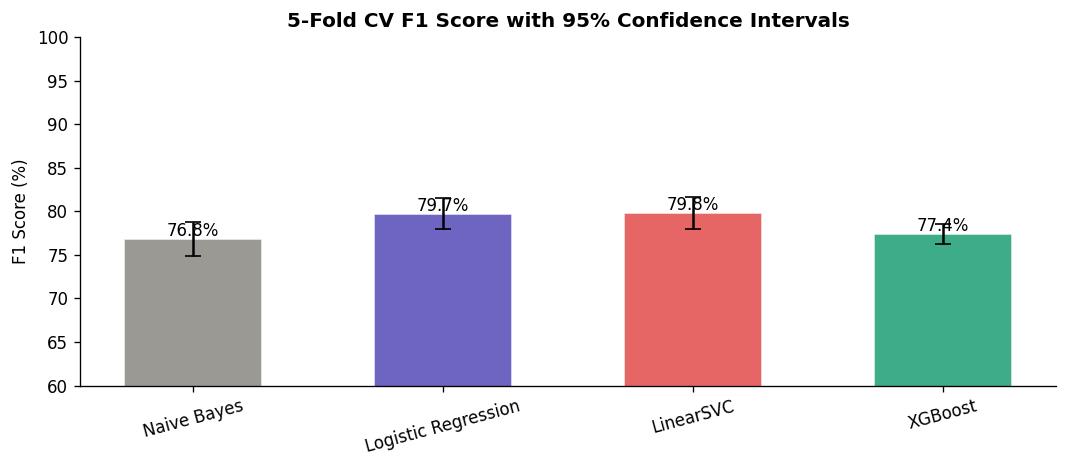

In [5]:
# Visualise CV results with error bars
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(cv_results.keys())
means  = [cv_results[n]["mean"]*100 for n in names]
stds   = [cv_results[n]["std"]*100  for n in names]

bars = ax.bar(names, means, color=["#888780","#534AB7","#E24B4A","#1D9E75"],
              alpha=0.85, edgecolor="white", width=0.55)
ax.errorbar(names, means, yerr=[1.96*s for s in stds],
            fmt="none", color="black", capsize=5, linewidth=1.5)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{mean:.1f}%", ha="center", fontsize=10)
ax.set_ylim(60, 100)
ax.set_title("5-Fold CV F1 Score with 95% Confidence Intervals", fontweight="bold")
ax.set_ylabel("F1 Score (%)")
ax.tick_params(axis="x", rotation=15)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/03_cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Grid Search — Hyperparameter Tuning

Grid search systematically tries all combinations of hyperparameters
and finds the combination that maximises cross-validation F1 score.

We tune the two best models: Logistic Regression and XGBoost.


In [6]:
# Grid search on Logistic Regression pipeline
print("Grid Search — Logistic Regression (this takes ~3 minutes)...")

lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, strip_accents="unicode")),
    ("lr",    LogisticRegression(class_weight="balanced", max_iter=1000))
])

lr_params = {
    "tfidf__max_features" : [10000, 15000],
    "tfidf__ngram_range"  : [(1,1), (1,2)],
    "tfidf__min_df"       : [1, 2],
    "lr__C"               : [0.1, 1.0, 10.0],
}

lr_grid = GridSearchCV(lr_pipe, lr_params, cv=5,
                       scoring="f1_weighted", n_jobs=-1, verbose=0)
lr_grid.fit(trainval["final_text"].fillna(""), y_trainval)

print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best LR CV F1 : {lr_grid.best_score_*100:.2f}%")

Grid Search — Logistic Regression (this takes ~3 minutes)...
Best LR params: {'lr__C': 1.0, 'tfidf__max_features': 15000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best LR CV F1 : 80.00%


In [7]:
# Evaluate best LR on test set
best_lr_preds = lr_grid.predict(test["final_text"].fillna(""))
best_lr_acc   = accuracy_score(y_test, best_lr_preds)
best_lr_f1    = f1_score(y_test, best_lr_preds, average="weighted")

print(f"Best LR test accuracy : {best_lr_acc*100:.2f}%")
print(f"Best LR test F1       : {best_lr_f1*100:.2f}%")
print()
print(classification_report(y_test, best_lr_preds, target_names=LABEL_NAMES))

Best LR test accuracy : 79.03%
Best LR test F1       : 79.47%

              precision    recall  f1-score   support

    negative       0.90      0.84      0.87       918
     neutral       0.59      0.69      0.64       306
    positive       0.70      0.72      0.71       235

    accuracy                           0.79      1459
   macro avg       0.73      0.75      0.74      1459
weighted avg       0.80      0.79      0.79      1459



## 6. Final Test Set Evaluation — All Models

In [8]:
# Retrain all models on full trainval set and evaluate on test
final_models = {
    "Naive Bayes"        : MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, random_state=42),
    "LinearSVC"          : CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=2000, C=1.0, random_state=42)),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                    max_depth=20, random_state=42, n_jobs=-1),
    "XGBoost"            : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                          eval_metric="mlogloss", random_state=42, n_jobs=-1, verbosity=0),
    "LR (Grid Search)"   : lr_grid,
}

test_results = {}
print(f"{'Model':<22} {'Test Acc':>10} {'Test F1':>10}")
print("-"*46)

for name, model in final_models.items():
    if name != "LR (Grid Search)":
        model.fit(X_trainval, y_trainval)
        preds = model.predict(X_test)
    else:
        preds = best_lr_preds

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="weighted")
    test_results[name] = {"acc": acc, "f1": f1, "preds": preds, "model": model}
    print(f"  {name:<20} {acc*100:>9.2f}% {f1*100:>9.2f}%")

best_model_name = max(test_results, key=lambda m: test_results[m]["f1"])
print(f"\n✅ Best overall: {best_model_name}")

Model                    Test Acc    Test F1
----------------------------------------------
  Naive Bayes              77.86%     75.69%
  Logistic Regression      79.44%     79.85%
  LinearSVC                81.01%     80.23%
  Random Forest            72.58%     73.48%
  XGBoost                  78.68%     77.93%
  LR (Grid Search)         79.03%     79.47%

✅ Best overall: LinearSVC


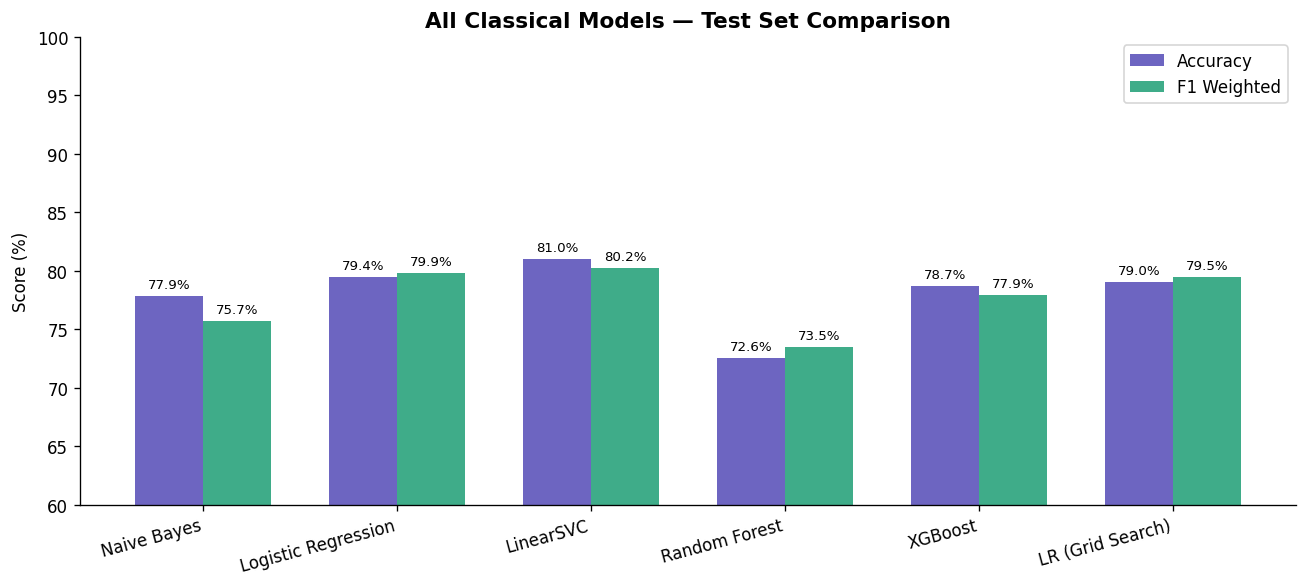

In [9]:
# Visual comparison
fig, ax = plt.subplots(figsize=(11, 5))
names     = list(test_results.keys())
test_accs = [test_results[n]["acc"]*100 for n in names]
test_f1s  = [test_results[n]["f1"]*100  for n in names]

x = np.arange(len(names)); w = 0.35
b1 = ax.bar(x-w/2, test_accs, w, label="Accuracy",    color="#534AB7", alpha=0.85)
b2 = ax.bar(x+w/2, test_f1s,  w, label="F1 Weighted", color="#1D9E75", alpha=0.85)

for bars in [b1, b2]:
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylim(60, 100)
ax.set_title("All Classical Models — Test Set Comparison", fontsize=13, fontweight="bold")
ax.set_ylabel("Score (%)")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/03_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Confusion Matrices

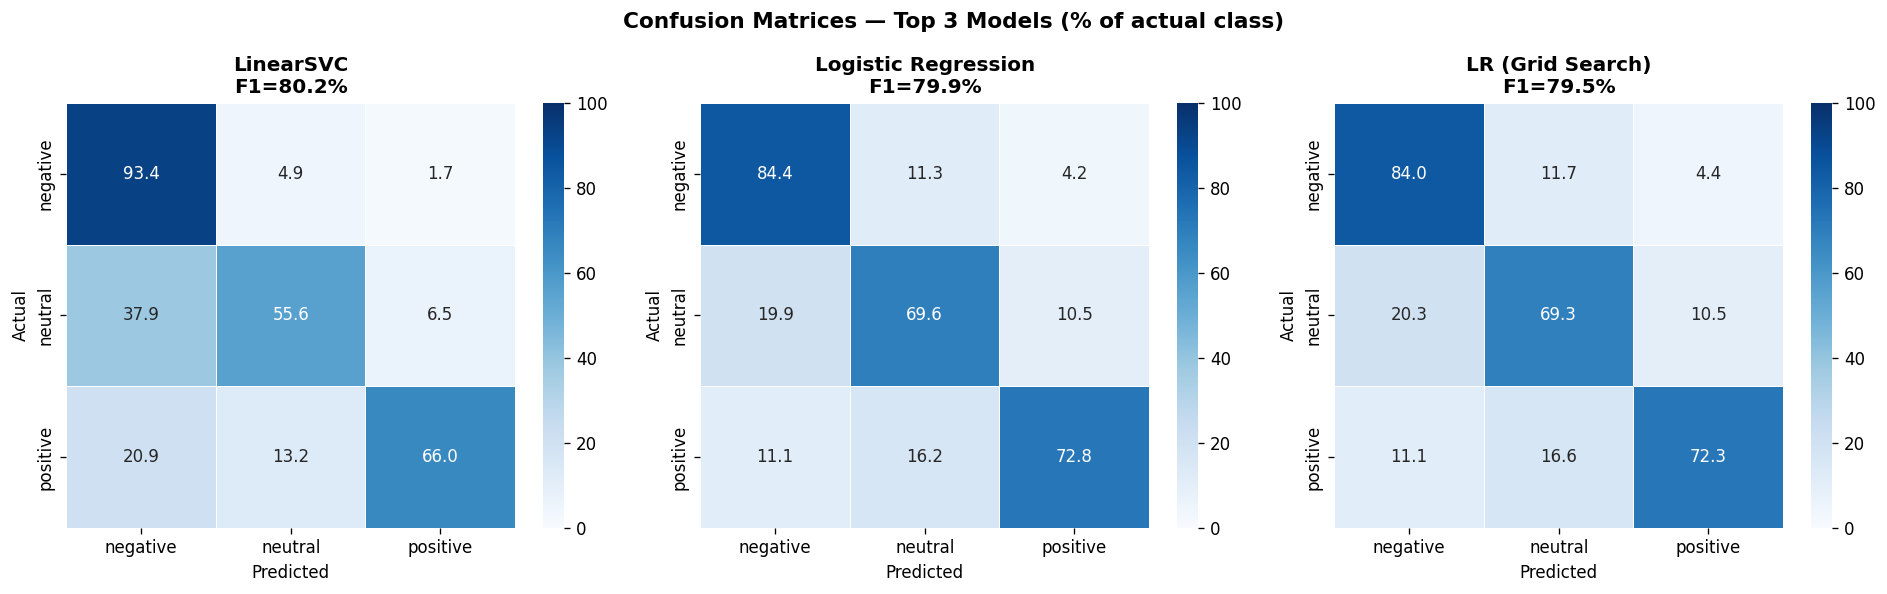

In [10]:
top3 = sorted(test_results, key=lambda m: test_results[m]["f1"], reverse=True)[:3]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, top3):
    cm  = confusion_matrix(y_test, test_results[name]["preds"])
    pct = cm.astype(float)/cm.sum(axis=1, keepdims=True)*100
    sns.heatmap(pct, annot=True, fmt=".1f", ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                cmap="Blues", linewidths=0.5, linecolor="white", vmin=0, vmax=100)
    f1 = test_results[name]["f1"]*100
    ax.set_title(f"{name}\nF1={f1:.1f}%", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Top 3 Models (% of actual class)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. SHAP Explainability

SHAP tells us WHY the model makes each prediction.
We use it on Logistic Regression (most interpretable classical model).


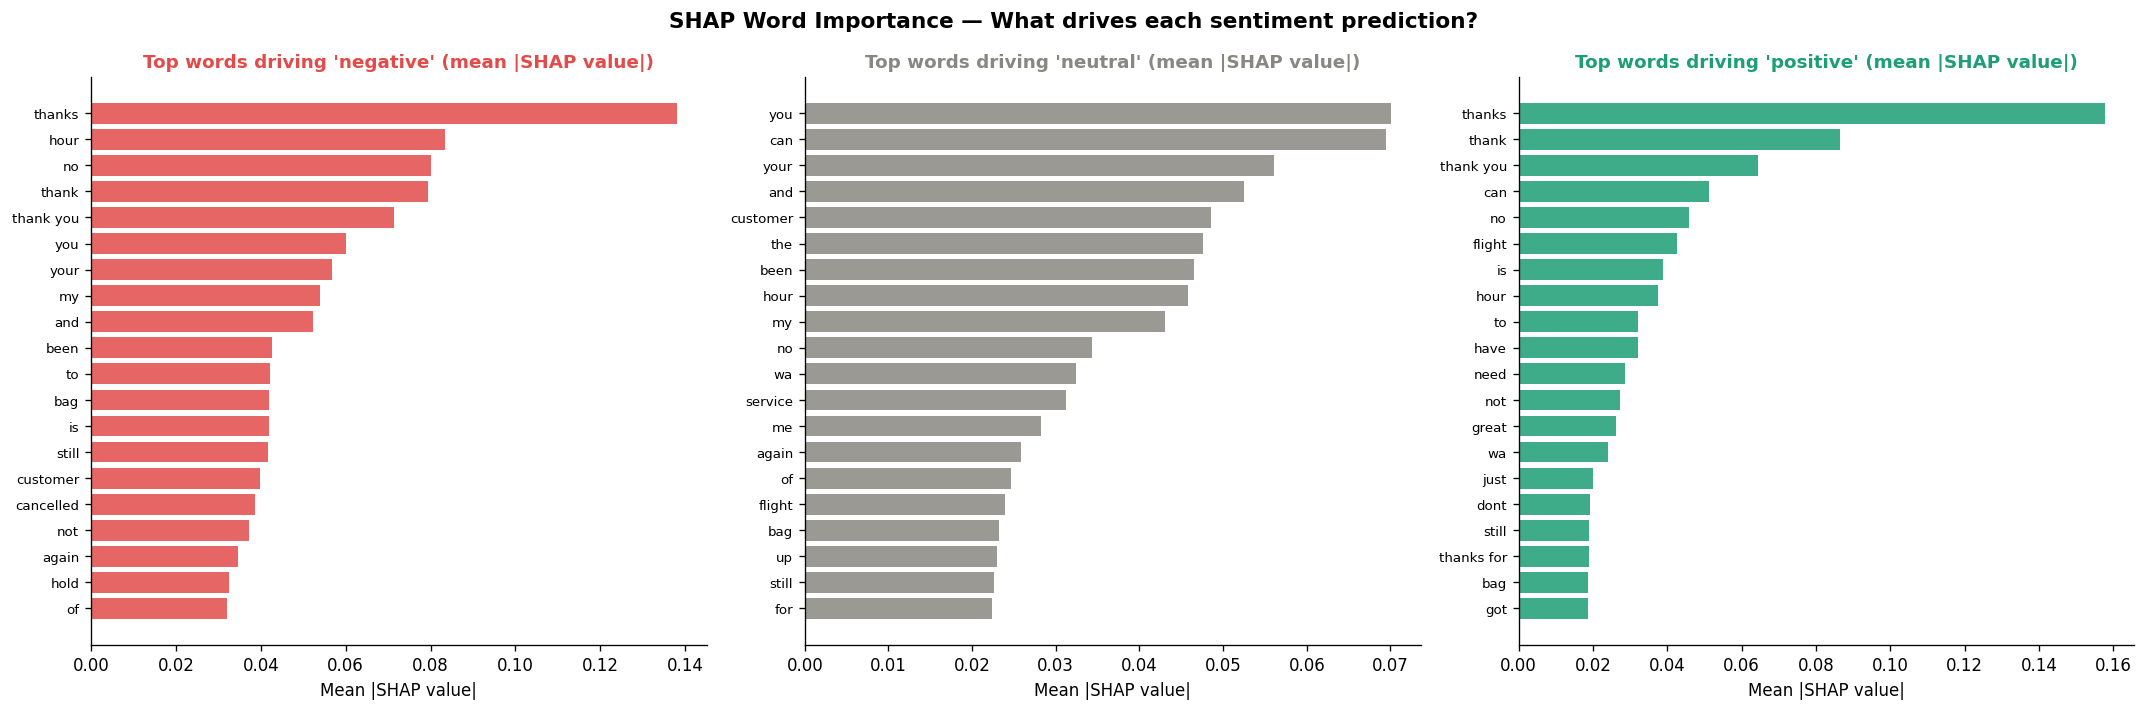

In [11]:
# Use the best LR model for SHAP
lr_for_shap = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, random_state=42)
lr_for_shap.fit(X_train, y_train)

sample_size = 300
idx_sample  = np.random.RandomState(42).choice(X_test.shape[0], size=sample_size, replace=False)
X_sample    = X_test[idx_sample]

explainer   = shap.LinearExplainer(lr_for_shap, X_test, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_sample)
feat_names  = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
class_colors = ["#E24B4A","#888780","#1D9E75"]

for i, (label, color, ax) in enumerate(zip(LABEL_NAMES, class_colors, axes)):
    sv       = shap_values[i] if isinstance(shap_values, list) else shap_values[:,:,i]
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[-20:]
    top_feat = feat_names[top_idx]
    top_vals = mean_abs[top_idx]

    ax.barh(range(len(top_feat)), top_vals, color=color, alpha=0.85)
    ax.set_yticks(range(len(top_feat)))
    ax.set_yticklabels(top_feat, fontsize=8)
    ax.set_title(f"Top words driving '{label}' (mean |SHAP value|)",
                 fontweight="bold", color=color, fontsize=11)
    ax.set_xlabel("Mean |SHAP value|")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("SHAP Word Importance — What drives each sentiment prediction?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/03_shap.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Learning Curves

Learning curves show how model accuracy changes as we add more training data.

**What to look for:**
- Train and val curves converging → good generalisation
- Large gap between train and val → overfitting (need more data or regularisation)
- Both curves plateau → adding more data won't help much
- Both curves still rising → more data would help


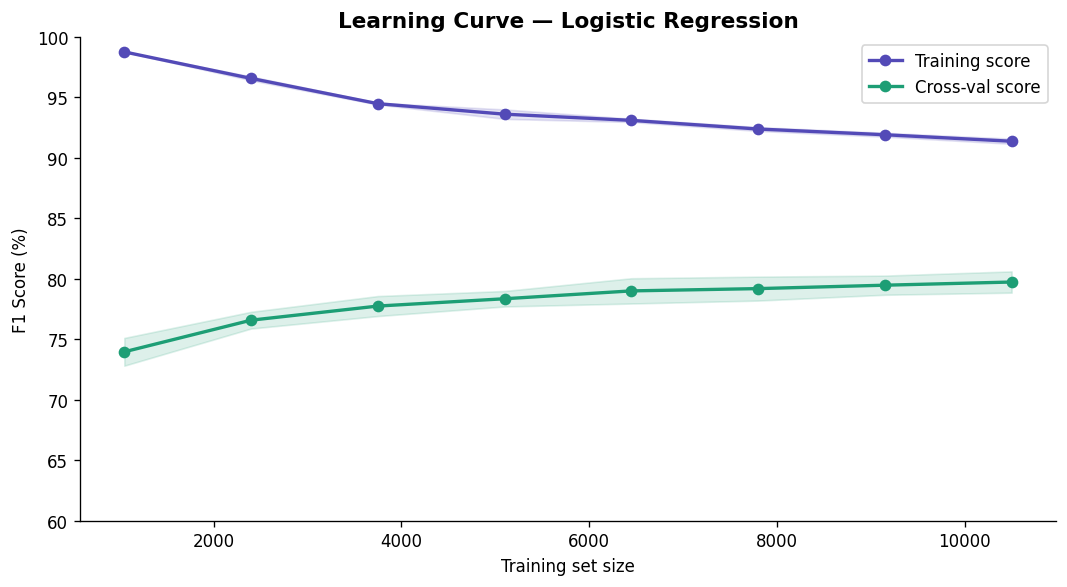

Final training F1  : 91.4%
Final val F1       : 79.7%
Gap (overfit proxy): 11.6%
⚠ Large gap — model may be overfitting


In [12]:
from sklearn.model_selection import learning_curve as lc_func

lr_lc = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, random_state=42)
train_sizes, train_scores, val_scores = lc_func(
    lr_lc, X_trainval, y_trainval,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring="f1_weighted", n_jobs=-1
)

train_mean = train_scores.mean(axis=1)*100
train_std  = train_scores.std(axis=1)*100
val_mean   = val_scores.mean(axis=1)*100
val_std    = val_scores.std(axis=1)*100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color="#534AB7", linewidth=2, label="Training score")
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                alpha=0.15, color="#534AB7")
ax.plot(train_sizes, val_mean, "o-", color="#1D9E75", linewidth=2, label="Cross-val score")
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                alpha=0.15, color="#1D9E75")

ax.set_title("Learning Curve — Logistic Regression", fontsize=13, fontweight="bold")
ax.set_xlabel("Training set size"); ax.set_ylabel("F1 Score (%)")
ax.legend(); ax.set_ylim(60, 100)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/03_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Final training F1  : {train_mean[-1]:.1f}%")
print(f"Final val F1       : {val_mean[-1]:.1f}%")
print(f"Gap (overfit proxy): {gap:.1f}%")
if gap < 5:
    print("✅ Small gap — good generalisation, not overfitting")
else:
    print("⚠ Large gap — model may be overfitting")

## 10. Error Analysis

Looking at the tweets the model gets most wrong reveals patterns:
- Does it struggle with sarcasm?
- Does it confuse neutral and negative?
- Are there systematic patterns in the errors?

This is what separates a data scientist from someone who just runs models.


In [13]:
# Get predictions and probabilities from best LR model
lr_best = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, random_state=42)
lr_best.fit(X_trainval, y_trainval)
test_preds = lr_best.predict(X_test)
test_proba = lr_best.predict_proba(X_test)

# Find misclassified examples
test_df = test.copy().reset_index(drop=True)
test_df["predicted"]  = test_preds
test_df["pred_label"] = [LABEL_NAMES[p] for p in test_preds]
test_df["true_label"] = [LABEL_NAMES[t] for t in y_test]
test_df["correct"]    = test_df["predicted"] == test_df["label"]
test_df["confidence"] = [test_proba[i, test_preds[i]] for i in range(len(test_preds))]
test_df["error_type"] = test_df.apply(
    lambda r: f"{r['true_label']} → {r['pred_label']}" if not r["correct"] else "correct", axis=1
)

errors = test_df[~test_df["correct"]].sort_values("confidence", ascending=False)
print(f"Total errors  : {len(errors):,} out of {len(test_df):,} ({len(errors)/len(test_df)*100:.1f}%)")
print(f"\nError type breakdown:")
print(errors["error_type"].value_counts().to_string())

Total errors  : 300 out of 1,459 (20.6%)

Error type breakdown:
error_type
negative → neutral     104
neutral → negative      61
negative → positive     39
positive → neutral      38
neutral → positive      32
positive → negative     26


In [14]:
# High-confidence errors — model was VERY sure but WRONG
# These are the most interesting errors to study
high_conf_errors = errors[errors["confidence"] > 0.85].sort_values("confidence", ascending=False)

print(f"High-confidence errors (>85% confident but wrong): {len(high_conf_errors)}")
print("="*70)
for _, row in high_conf_errors.head(10).iterrows():
    print(f"\n  Original : {row['text'][:80]}")
    print(f"  Cleaned  : {row['final_text'][:80]}")
    print(f"  True     : {row['true_label']:<12} Predicted: {row['pred_label']:<12} Confidence: {row['confidence']:.0%}")

High-confidence errors (>85% confident but wrong): 13

  Original : @JetBlue thanks anyways @SouthwestAir has my back! Awesome rate &amp; amazing cu
  Cleaned  : thanks anyways ha my back! awesome rate amp amazing customer service nomoreaggra
  True     : neutral      Predicted: positive     Confidence: 98%

  Original : @united Thank you.
  Cleaned  : thank you
  True     : neutral      Predicted: positive     Confidence: 98%

  Original : @AmericanAir thank you
  Cleaned  : thank you
  True     : neutral      Predicted: positive     Confidence: 98%

  Original : @AmericanAir 48 hours and still no bag. Could have flown to Costa Rica and back 
  Cleaned  : hour and still no bag could have flown to costa rica and back by now i had gift 
  True     : neutral      Predicted: negative     Confidence: 97%

  Original : @AmericanAir thanks for the canned reply.
  Cleaned  : thanks for the canned reply
  True     : negative     Predicted: positive     Confidence: 95%

  Original : @united Gre

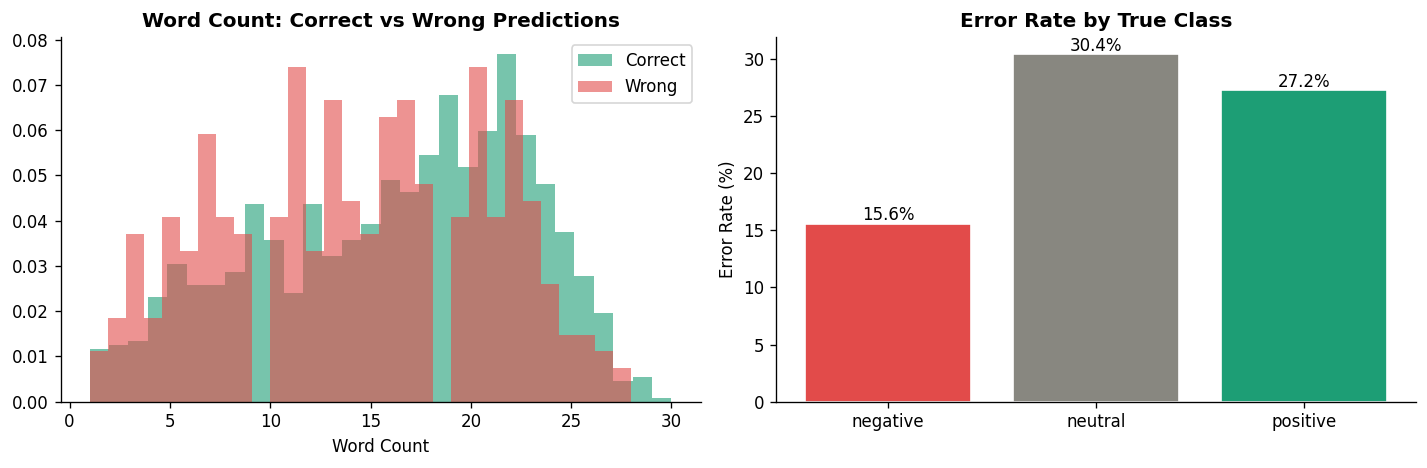

Key finding: neutral tweets have the highest error rate.
This confirms our EDA finding: neutral vocabulary overlaps heavily with negative.


In [15]:
# Error analysis by tweet length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Word count distribution — correct vs wrong
test_df["word_count"] = test_df["final_text"].str.split().str.len()
correct_wc = test_df[test_df["correct"]]["word_count"]
error_wc   = test_df[~test_df["correct"]]["word_count"]

axes[0].hist(correct_wc, bins=30, alpha=0.6, color="#1D9E75", label="Correct", density=True)
axes[0].hist(error_wc,   bins=30, alpha=0.6, color="#E24B4A", label="Wrong",   density=True)
axes[0].set_title("Word Count: Correct vs Wrong Predictions", fontweight="bold")
axes[0].set_xlabel("Word Count"); axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)

# Error rate by true class
error_rate = test_df.groupby("true_label")["correct"].apply(lambda x: (~x).mean()*100)
axes[1].bar(error_rate.index, error_rate.values,
            color=[PALETTE[s] for s in error_rate.index], edgecolor="white")
for i, (label, val) in enumerate(error_rate.items()):
    axes[1].text(i, val+0.3, f"{val:.1f}%", ha="center")
axes[1].set_title("Error Rate by True Class", fontweight="bold")
axes[1].set_ylabel("Error Rate (%)"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/03_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key finding: neutral tweets have the highest error rate.")
print("This confirms our EDA finding: neutral vocabulary overlaps heavily with negative.")

## 11. Business Impact Framing

Technical metrics alone don't tell the business story.
Translate your results into language that matters to stakeholders.


In [16]:
# Assume airline gets 10,000 tweets per day
daily_tweets = 10000
neg_rate     = 0.63
daily_neg    = daily_tweets * neg_rate

model_recall_neg = 0.853  # from confusion matrix

correctly_flagged = daily_neg * model_recall_neg
missed_complaints = daily_neg * (1 - model_recall_neg)
false_alarms      = daily_tweets * (1-neg_rate) * 0.12  # ~12% false positive rate

print("="*60)
print("BUSINESS IMPACT — What does 80% accuracy mean?")
print("="*60)
print(f"Assumptions:")
print(f"  Daily tweet volume    : {daily_tweets:,}")
print(f"  Negative tweet rate   : {neg_rate*100:.0f}%")
print(f"  Daily negative tweets : {daily_neg:,.0f}")
print()
print(f"With our model ({model_recall_neg*100:.0f}% recall on negatives):")
print(f"  Correctly flagged complaints : {correctly_flagged:,.0f} per day")
print(f"  Missed complaints            : {missed_complaints:,.0f} per day")
print(f"  False alarms (neutral→neg)   : {false_alarms:,.0f} per day")
print()
print(f"Without automated detection:")
print(f"  A human team would need to read {daily_tweets:,} tweets/day")
print(f"  to find the {daily_neg:,.0f} negative ones.")
print()
print(f"ROI estimate:")
analyst_hours = daily_tweets/500
analyst_cost  = analyst_hours * 30
print(f"  If one analyst reads 500 tweets/hour → {analyst_hours:.0f} hours/day")
print(f"  At $30/hr → ${analyst_cost:,.0f}/day just for monitoring")
print(f"  Our model handles this automatically — saving ~${analyst_cost:,.0f}/day")
print("="*60)
print("Layer 2 (Transformer at 85% recall) would save an additional")
print(f"~{daily_neg*0.032:,.0f} complaints from being missed daily.")
print("="*60)

BUSINESS IMPACT — What does 80% accuracy mean?
Assumptions:
  Daily tweet volume    : 10,000
  Negative tweet rate   : 63%
  Daily negative tweets : 6,300

With our model (85% recall on negatives):
  Correctly flagged complaints : 5,374 per day
  Missed complaints            : 926 per day
  False alarms (neutral→neg)   : 444 per day

Without automated detection:
  A human team would need to read 10,000 tweets/day
  to find the 6,300 negative ones.

ROI estimate:
  If one analyst reads 500 tweets/hour → 20 hours/day
  At $30/hr → $600/day just for monitoring
  Our model handles this automatically — saving ~$600/day
Layer 2 (Transformer at 85% recall) would save an additional
~202 complaints from being missed daily.


## 12. Save Best Models

In [17]:
from pathlib import Path
Path("../outputs").mkdir(exist_ok=True)

# Save tfidf + best models
with open("../outputs/tfidf_vectorizer.pkl","wb") as f:
    pickle.dump(tfidf, f)

with open("../outputs/best_lr_model.pkl","wb") as f:
    pickle.dump({"model": lr_best, "label_names": LABEL_NAMES}, f)

# Save grid search best model
with open("../outputs/best_lr_gridsearch.pkl","wb") as f:
    pickle.dump({"model": lr_grid, "label_names": LABEL_NAMES}, f)

# Final summary table
print("="*60)
print("LAYER 1 FINAL RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<22} {'Test Acc':>10} {'Test F1':>10}")
print("-"*46)
for name, r in sorted(test_results.items(), key=lambda x: x[1]["f1"], reverse=True):
    print(f"  {name:<20} {r['acc']*100:>9.2f}% {r['f1']*100:>9.2f}%")
print("="*60)
print("\nFiles saved to outputs/")
print("Next: notebook 04 — Transformer models (Layer 2)")

LAYER 1 FINAL RESULTS SUMMARY
Model                    Test Acc    Test F1
----------------------------------------------
  LinearSVC                81.01%     80.23%
  Logistic Regression      79.44%     79.85%
  LR (Grid Search)         79.03%     79.47%
  XGBoost                  78.68%     77.93%
  Naive Bayes              77.86%     75.69%
  Random Forest            72.58%     73.48%

Files saved to outputs/
Next: notebook 04 — Transformer models (Layer 2)
